In [ ]:
rm -r /content/drive/MyDrive/AnimaRepel/Default_ndan

In [ ]:

!pip install imutils playsound ipywidgets --quiet
!pip install pygobject

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imports
import os
import cv2
import time
import json
import base64
import numpy as np
import tensorflow as tf
import shutil
from playsound import playsound
from google.colab import files
from IPython.display import display, Javascript, Image, clear_output
import ipywidgets as widgets
from google.colab.output import eval_js

# Constants for image dimensions, batch size, training epochs etc.
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15  # Adjust the number of epochs as needed

# Base directory for storing data
DATA_DIR = '/content/drive/MyDrive/AnimaRepel'
if not os.path.exists(DATA_DIR):
    os.mkdir(DATA_DIR)

# Global variable to mark the class that should trigger the buzzer during inference.
buzzer_class = None


In [ ]:
# --- Helper Function: Capture a photo from the webcam (single capture) ---
def take_photo(filename='photo.jpg', quality=0.8):
    """
    Captures a photo using the user's webcam via JavaScript and saves it to filename.
    """
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const captureButton = document.createElement('button');
          captureButton.textContent = 'Capture';
          div.appendChild(captureButton);
          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();
          // Adjust iframe height.
          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
          // Wait for the Capture button click.
          await new Promise((resolve) => captureButton.onclick = resolve);
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();
          div.remove();
          return canvas.toDataURL('image/jpeg', quality);
        }
        ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = np.array(bytearray(base64.b64decode(data.split(',')[1])), dtype=np.uint8)
    img = cv2.imdecode(binary, cv2.IMREAD_COLOR)
    cv2.imwrite(filename, img)
    print(f'Photo saved as {filename}')
    return filename

# --- Helper Function: Capture multiple photos continuously ---
def take_photos_continuous(duration=5, quality=0.8, interval=0.5):
    """
    Captures multiple photos continuously from the webcam for a given duration (in seconds).
    Returns a list of file paths for the saved images.
    """
    # JavaScript code to capture multiple frames.
    js_code = f'''
        async function takePhotos(duration, quality, interval) {{
          const div = document.createElement('div');
          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({{video: true}});
          div.appendChild(video);
          document.body.appendChild(div);
          video.srcObject = stream;
          await video.play();
          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          let photos = [];
          const sleep = (ms) => new Promise(resolve => setTimeout(resolve, ms));
          const startTime = Date.now();
          while ((Date.now() - startTime) < duration * 1000) {{
              canvas.getContext('2d').drawImage(video, 0, 0);
              photos.push(canvas.toDataURL('image/jpeg', quality));
              await sleep(interval * 1000);
          }}
          stream.getVideoTracks()[0].stop();
          div.remove();
          return JSON.stringify(photos);
        }}
        takePhotos({duration}, {quality}, {interval});
    '''
    photos_json = eval_js(js_code)
    photos_data = json.loads(photos_json)
    # Save each photo to a file and collect filenames.
    filenames = []
    for idx, data in enumerate(photos_data):
        binary = np.array(bytearray(base64.b64decode(data.split(',')[1])), dtype=np.uint8)
        img = cv2.imdecode(binary, cv2.IMREAD_COLOR)
        filename = f'captured_{int(time.time())}_{idx}.jpg'
        cv2.imwrite(filename, img)
        filenames.append(filename)
    print(f"Captured {len(filenames)} images over {duration} seconds.")
    return filenames


In [ ]:
# --- Data Collection Interactive UI ---
# Widget for entering a new class name.
class_name_text = widgets.Text(
    value='',
    placeholder='Enter object class name',
    description='Class Name:',
    disabled=False
)

# Button for capturing multiple images.
capture_button = widgets.Button(
    description='Capture Images (5 sec)',
    button_style='success',
    tooltip='Capture images continuously for 5 seconds for the specified class'
)

capture_output = widgets.Output()

# A separate button to flag the current class as one that should trigger the buzzer.
flag_button = widgets.Button(
    description='Flag Class for Buzzer',
    button_style='danger',
    tooltip='Flag the current class to trigger buzzer in live inference'
)

# Open Camera button
open_camera_button = widgets.Button(description="Open Camera", button_style="info")

# Function to open camera
def open_camera_callback(b):
    js_code = '''
        async function openCamera() {
            const div = document.createElement('div');
            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            div.appendChild(video);
            document.body.appendChild(div);
            video.srcObject = stream;
            await video.play();
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        }
        openCamera();
    '''
    display(Javascript(js_code))

# Function to capture images and save them in "dang" or "ndan" folders
def capture_images_callback(b):
    with capture_output:
        clear_output(wait=True)
        cls_name = class_name_text.value.strip()
        if cls_name == '':
            print("Please enter a valid class name.")
            return

        # Check if the current class is flagged as dangerous or not
        flag = 'dang' if buzzer_class == cls_name else 'ndan'

        # Create directories for the class, separate by "dang" or "ndan"
        class_dir = os.path.join(DATA_DIR, f"{cls_name}_{flag}")
        if not os.path.exists(class_dir):
            os.makedirs(class_dir)
            print(f"Created folder for class: {cls_name}_{flag}")

        # Capture continuous photos for 5 seconds.
        filenames = take_photos_continuous(duration=5, quality=0.8, interval=0.5)

        # Move captured files into the corresponding "dang" or "ndan" folder.
        for fname in filenames:
            dest = os.path.join(class_dir, f"{cls_name}_{flag}_{os.path.basename(fname)}")
            shutil.move(fname, dest)
        print(f"Captured {len(filenames)} images for class '{cls_name}_{flag}' and saved to folder {class_dir}.")

# Attach the callback to the capture button
capture_button.on_click(capture_images_callback)

# Flag class for buzzer callback
def flag_class_callback(b):
    global buzzer_class
    cls_name = class_name_text.value.strip()
    if cls_name == '':
        with capture_output:
            print("Enter a valid class name to flag.")
    else:
        buzzer_class = cls_name
        with capture_output:
            print(f"Class '{cls_name}' flagged to trigger buzzer sound during live inference.")

# Attach the callback to the flag button
flag_button.on_click(flag_class_callback)

# Display UI with Open Camera button, class name input, and action buttons
print("### Data Collection: Enter a class name, capture images, and optionally flag a class for buzzer ###")
display(class_name_text, widgets.HBox([capture_button, flag_button, open_camera_button]), capture_output)

# Ensure buzzer_class is printed to debug
print("Current buzzer class: ", buzzer_class)


### Data Collection: Enter a class name, capture images, and optionally flag a class for buzzer ###


Text(value='', description='Class Name:', placeholder='Enter object class name')

Output()

Current buzzer class:  None


In [ ]:
# --- Model Training Interactive UI ---
train_status = widgets.Output()

train_button = widgets.Button(
    description='Train Model',
    button_style='warning',
    tooltip='Train the model using collected images'
)

def train_model_callback(b):
    with train_status:
        clear_output(wait=True)
        print("Preparing data generators...")

        from tensorflow.keras.preprocessing.image import ImageDataGenerator

        # Updated to create a 80/10/10 split for training, validation, and testing
        datagen_train = ImageDataGenerator(
            rescale=1./255,
            validation_split=0.2, # 20% for validation and testing
            rotation_range=20,
            zoom_range=0.3,
            horizontal_flip=True,
            vertical_flip=True
        )

        datagen_test_val = ImageDataGenerator(
            rescale=1./255,
            validation_split=0.5 # Split the 20% into 10% validation and 10% testing
        )


        train_generator = datagen_train.flow_from_directory(
            DATA_DIR,
            target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            subset='training'
        )

        validation_generator = datagen_test_val.flow_from_directory(
            DATA_DIR,
            target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            subset='validation'
        )

        test_generator = datagen_test_val.flow_from_directory(
            DATA_DIR,
            target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            subset='training' # Use 'training' subset of the 20% for testing
        )


        print("Building model with transfer learning...")
        base_model = tf.keras.applications.MobileNetV2(
            input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet'
        )
        base_model.trainable = False

        model = tf.keras.models.Sequential([
            base_model,
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
        ])

        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        model.summary(print_fn=lambda x: print(x))

        print("Starting training...")
        history = model.fit(
            train_generator,
            validation_data=validation_generator,
            epochs=EPOCHS
        )

        # Save the trained model
        model.save('object_identifier_model.h5')
        print("Model trained and saved as object_identifier_model.h5.")
        global saved_class_indices, test_gen  # Make test_gen global to use in evaluation cell
        saved_class_indices = train_generator.class_indices
        test_gen = test_generator # Save test generator

train_button.on_click(train_model_callback)

print("\n### Model Training ###")
display(train_button, train_status)


### Model Training ###


Button(button_style='warning', description='Train Model', style=ButtonStyle(), tooltip='Train the model using …

Output()

In [ ]:
# === EXPORT MODEL + CLASS INDICES (RUN THIS AFTER TRAINING) ===
import tensorflow as tf
import json
import os

EXPORT_DIR = '/content/drive/MyDrive/AnimaRepel'

# 1) Load the trained Keras model from the notebook
model = tf.keras.models.load_model('object_identifier_model.h5', compile=False)

# 2) Save in new .keras format (optional but nice to have)
keras_path = os.path.join(EXPORT_DIR, 'object_identifier_model.keras')
model.save(keras_path)
print(f"Saved new model as: {keras_path}")

# 3) Convert and save as TFLite
tflite_path = os.path.join(EXPORT_DIR, 'object_identifier_model.tflite')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"Saved TFLite model as: {tflite_path}")

# 4) Save class_indices.json (uses saved_class_indices from training callback)
json_path = os.path.join(EXPORT_DIR, 'class_indices.json')
with open(json_path, 'w') as f:
    json.dump(saved_class_indices, f)

print("Saved class_indices.json:", saved_class_indices)
print("=== EXPORT COMPLETE ===")


Saved new model as: /content/drive/MyDrive/AnimaRepel/object_identifier_model.keras
Saved artifact at '/tmp/tmptkb4x67y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 11), dtype=tf.float32, name=None)
Captures:
  134015205930192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134015196051216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134015196048528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134015352537360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134015205924432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134015196052368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134015196051408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134015196051600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134015196048336: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
import tensorflow as tf

# 1) Load your old H5 model (this works fine in Colab)
model = tf.keras.models.load_model('object_identifier_model.h5', compile=False)

# 2) Save it in new Keras format
model.save('/content/drive/MyDrive/AnimaRepel/object_identifier_model.keras')  # this creates a .keras file
print("Saved new model as object_identifier_model.keras")


Saved new model as object_identifier_model.keras


In [ ]:
import tensorflow as tf

# Load your working model in Colab
model = tf.keras.models.load_model('object_identifier_model.h5', compile=False)

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save as .tflite file
with open('/content/drive/MyDrive/AnimaRepel/object_identifier_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Saved TFLite model as object_identifier_model.tflite")


Saved artifact at '/tmp/tmpuz2e4vlm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 80, 80, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 11), dtype=tf.float32, name=None)
Captures:
  138239698377552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138239698385040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138239698383696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138239698376208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138239698386000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138239698375824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138239698385616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138239698386576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138239698374096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138239698382736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13823969838408

In [ ]:
import json

with open('/content/drive/MyDrive/AnimaRepel/class_indices.json', 'w') as f:
    json.dump(saved_class_indices, f)

print("Saved class_indices.json:", saved_class_indices)

Saved class_indices.json: {'.ipynb_checkpoints': 0, 'Default_ndan': 1, 'Elephants_dang': 2, 'GiantSquirrel_dang': 3, 'Human1_ndan': 4, 'Human_ndan': 5, 'Parrot_dang': 6, 'Peacock1_dang': 7, 'Porcupine_dang': 8, 'Rabbit_dang': 9, 'Toque_Macaque_dang': 10}


In [ ]:
# %% [code]
# — Evaluate saved .h5 robustly (Keras 3-safe) —
import os, math, numpy as np, tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Config ---
MODEL_PATH = 'object_identifier_model.h5'              # change if needed
TEST_DIR   = '/content/drive/MyDrive/AnimaRepel_test'   # preferred: fixed test-only folder
DATA_DIR   = '/content/drive/MyDrive/AnimaRepel'        # fallback: split from here
IMG_SIZE   = 224 # Changed from 224 to 286 to match training
BATCH_SIZE = 16

# 0) Make each run clean
tf.keras.backend.clear_session()

# 1) Load model WITHOUT compiling (avoids positional-arg deserialization bugs)
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"MODEL_PATH not found: {MODEL_PATH}")
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print(f"Loaded model from: {MODEL_PATH}")

# 2) Compile explicitly (match your training setup)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3) Build a clean, non-augmenting test generator
def build_test_gen_from_dir(directory):
    if not os.path.isdir(directory):
        return None
    datagen = ImageDataGenerator(rescale=1./255)  # no aug for eval
    gen = datagen.flow_from_directory(
        directory,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    return gen

test_gen = build_test_gen_from_dir(TEST_DIR)
if test_gen is None:
    print(f"NOTE: {TEST_DIR} not found. Falling back to deterministic split from DATA_DIR.")
    datagen = ImageDataGenerator(rescale=1./255, validation_split=0.5)
    test_gen = datagen.flow_from_directory(
        DATA_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',   # use first half of the 20% holdout
        shuffle=False
    )

if test_gen.samples == 0:
    raise RuntimeError("No images found for evaluation. Ensure class subfolders contain images.")

# 4) Evaluate
steps = math.ceil(test_gen.samples / float(BATCH_SIZE))
test_gen.reset()
loss, acc = model.evaluate(test_gen, steps=steps, verbose=0)
print(f"\nTest samples: {test_gen.samples}")
print(f"Overall Accuracy: {acc*100:.2f}%")
print(f"Loss: {loss:.4f}")

# 5) Optional sanity check
y_true = test_gen.classes
y_prob = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
print(f"Sanity-check Accuracy: {(y_pred == y_true).mean()*100:.2f}%")

Loaded model from: object_identifier_model.h5
NOTE: /content/drive/MyDrive/AnimaRepel_test not found. Falling back to deterministic split from DATA_DIR.
Found 281 images belonging to 11 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Test samples: 281
Overall Accuracy: 99.29%
Loss: 0.0180
Sanity-check Accuracy: 99.29%


Generating confusion matrix...
Found 473 images belonging to 11 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


473/473 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step

Classification Report:
                    precision    recall  f1-score   support

      Default_ndan       1.00      1.00      1.00         8
    Elephants_dang       1.00      1.00      1.00        65
GiantSquirrel_dang       1.00      0.98      0.99        44
       Human1_ndan       1.00      0.62      0.77         8
        Human_ndan       0.73      1.00      0.84         8
       Parrot_dang       1.00      1.00      1.00        22
     Peacock1_dang       1.00      1.00      1.00        81
    Porcupine_dang       1.00      1.00      1.00       163
       Rabbit_dang       0.97      1.00      0.99        35
 ToqueMacaque_dang       1.00      1.00      1.00        39

          accuracy                           0.99       473
         macro avg       0.97      0.96      0.96       473
      weighted avg       0.99      0.99      0.99       473



<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

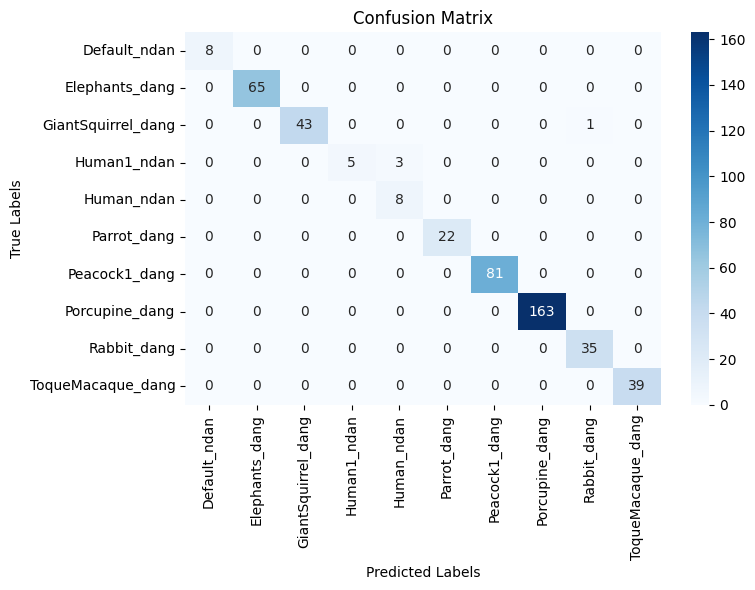

In [ ]:
# --- Fixed Confusion Matrix Visualization ---

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("Generating confusion matrix...")

# Reload model (in case this cell runs separately)
model = tf.keras.models.load_model('object_identifier_model.h5', compile=False)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.8571) # Changed from 0.2 to 0.8571

validation_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,  # Use batch size = 1 for per-image predictions
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# True labels and predicted labels
true_labels = validation_generator.classes
predictions = model.predict(validation_generator, verbose=1)
predicted_labels = np.argmax(predictions, axis=1)

# Extract only the classes actually present in the validation set
unique_labels = sorted(list(set(true_labels)))
class_names = [list(validation_generator.class_indices.keys())[i] for i in unique_labels]

# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels, labels=unique_labels)

# Print classification report safely
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, labels=unique_labels, target_names=class_names, zero_division=0))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt

In [ ]:
#%% [code]
# --- Real-Time Inference Live View UI ---
# print("\nUpload buzzer sound file (buzzer.wav) if you haven't already:")
# uploaded_files = files.upload()

from IPython.display import Audio  # Import Audio for sound playback

test_status = widgets.Output()
live_button = widgets.Button(
    description='Start Live View Inference',
    button_style='info',
    tooltip='Start live inference: show camera view with predicted class overlay'
)

# Load trained model and class indices.
if os.path.exists('object_identifier_model.h5'):
    model = tf.keras.models.load_model('object_identifier_model.h5')
    try:
        class_indices = saved_class_indices  # from training callback
    except NameError:
        from tensorflow.keras.preprocessing.image import ImageDataGenerator
        temp_datagen = ImageDataGenerator(rescale=1./255)
        temp_generator = temp_datagen.flow_from_directory(
            DATA_DIR,
            target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE,
            class_mode='categorical'
        )
        class_indices = temp_generator.class_indices
    index_to_class = {v: k for k, v in class_indices.items()}
    print("Model and class indices loaded.")
else:
    model = None
    print("No trained model found. Please train the model first.")

def preprocess_image_from_data(image_data):
    binary = np.array(bytearray(base64.b64decode(image_data.split(',')[1])), dtype=np.uint8)
    img = cv2.imdecode(binary, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img

def live_inference_callback(b):
    if model is None:
        with test_status:
            clear_output(wait=True)
            print("Please train the model first!")
        return
    with test_status:
        clear_output(wait=True)
        print("Starting live inference (will run for 20 seconds)...")
        start_time = time.time()
        while time.time() - start_time < 200:
            # Capture a frame using JavaScript.
            js_code = '''
                async function captureFrame(quality) {
                  const div = document.createElement('div');
                  const video = document.createElement('video');
                  video.style.display = 'block';
                  const stream = await navigator.mediaDevices.getUserMedia({video: true});
                  div.appendChild(video);
                  document.body.appendChild(div);
                  video.srcObject = stream;
                  await video.play();
                  google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
                  const canvas = document.createElement('canvas');
                  canvas.width = video.videoWidth;
                  canvas.height = video.videoHeight;
                  canvas.getContext('2d').drawImage(video, 0, 0);
                  stream.getVideoTracks()[0].stop();
                  div.remove();
                  return canvas.toDataURL('image/jpeg', quality);
                }
                captureFrame(0.8);
            '''
            frame_data = eval_js(js_code)
            # Preprocess captured frame.
            frame = preprocess_image_from_data(frame_data)
            # Prepare input for prediction.
            input_img = np.expand_dims(frame.astype("float32") / 255.0, axis=0)
            predictions = model.predict(input_img)
            predicted_index = int(np.argmax(predictions[0]))
            predicted_class = index_to_class[predicted_index]
            confidence = predictions[0][predicted_index]
            label = f"{predicted_class} ({confidence*100:.2f}%)"
            # Overlay text on frame using OpenCV.
            display_frame = cv2.putText(frame.copy(), label, (10, 30),
                                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
            # Encode frame for display.
            _, buffer = cv2.imencode('.jpg', cv2.cvtColor(display_frame, cv2.COLOR_RGB2BGR))
            img_bytes = buffer.tobytes()
            clear_output(wait=True)
            display(Image(data=img_bytes))
            # Check for buzzer trigger.
            # ---- Conventional if/else: play if 'dang', stop if 'ndan' ----
            pred_lower = predicted_class.lower()

            if 'dang' in pred_lower:
                print(f"[DANG] {label} → buzzer ON")
                display(Audio("buzzer.wav", autoplay=True))
                # Try JS-controlled audio (lets us stop it later)

            elif 'ndan' in pred_lower:
                print(f"[NDAN] {label} → buzzer OFF")
                # Stop the persistent audio if it’s playing
                try:
                    eval_js('const a=document.getElementById("buzzer-audio"); if(a){a.pause(); a.currentTime=0;}')
                except Exception:
                    # No-op if JS control fails; we only avoid playing new sounds
                    pass
            else:
                # Neither tag found; don’t change buzzer state, just print prediction
                print(f"Prediction: {label}")
# ---------------------------------------------------------------

            # Brief pause before next frame.
            time.sleep(0.5)
        print("Live inference session ended.")

live_button.on_click(live_inference_callback)

print("\n### Real-Time Inference Live View ###")
display(live_button, test_status)


Model and class indices loaded.

### Real-Time Inference Live View ###


Button(button_style='info', description='Start Live View Inference', style=ButtonStyle(), tooltip='Start live …

Output()